In [1]:
print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd

trades = pd.read_csv('historical_data.csv')
fear = pd.read_csv('fear_greed_index.csv')

print("Trades shape:", trades.shape)
print("Fear shape:", fear.shape)

Trades shape: (211224, 16)
Fear shape: (2644, 4)


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

In [6]:
fear.columns.tolist()

['timestamp', 'value', 'classification', 'date']

In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [10]:
#create matching datasets
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date

fear['date'] = pd.to_datetime(
    fear['date']
).dt.date

In [11]:
#merge both datasets
merged = pd.merge(
    trades,
    fear[['date', 'classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [12]:
#check
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [13]:
#Analysis 1: Average Profit by Sentiment
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

avg_pnl


,Closed PnL
classification,
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Extreme Fear,34.537862
Neutral,34.307718


In [14]:
#Analysis 2: Total Profit by Sentiment
total_pnl = merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

total_pnl


,Closed PnL
classification,
Fear,3.357155e+06
Extreme Greed,2.715171e+06
Greed,2.150129e+06
Neutral,1.292921e+06
Extreme Fear,7.391102e+05


In [15]:
#Analysis 3: Win Rate
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean() * 100

win_rate


,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


In [ ]:
#The graphs

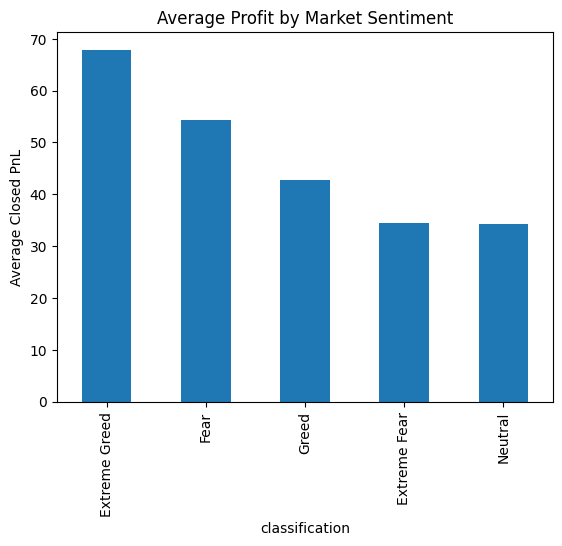

In [16]:
import matplotlib.pyplot as plt

avg_pnl.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

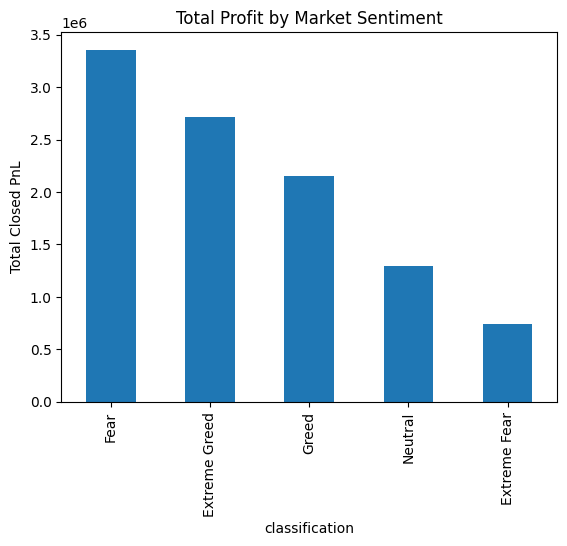

In [17]:
total_pnl.plot(kind='bar')

plt.title('Total Profit by Market Sentiment')
plt.ylabel('Total Closed PnL')
plt.show()

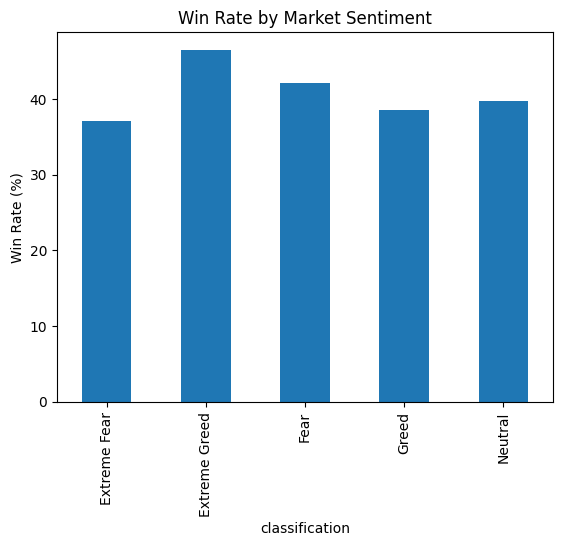

In [18]:
win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

In [19]:
trade_size = merged.groupby('classification')['Size USD'].mean().sort_values(ascending=False)

trade_size

,Size USD
classification,
Fear,7816.109931
Greed,5736.884375
Extreme Fear,5349.731843
Neutral,4782.732661
Extreme Greed,3112.251565


In [20]:
side_analysis = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

side_analysis

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

This analysis investigates how Bitcoin market sentiment (Fear & Greed Index) influences trader performance using Hyperliquid historical trading data. The goal is to identify patterns in profitability, win rates, and trading behavior across different market sentiment conditions.

# Key Findings

1. Extreme Greed generated the highest average profit per trade (67.89).

2. Fear periods generated the highest total profit (3.36M) due to larger trading volume.

3. Extreme Greed achieved the highest win rate (46.49%).

4. Fear periods had the largest average trade sizes (~7816 USD), indicating greater capital deployment.

5. Extreme Fear produced the lowest win rate (37.06%).

6. SELL trades significantly outperformed BUY trades during Greed and Extreme Greed conditions.

7. Extreme Greed showed the strongest profitability despite having the smallest average trade size.